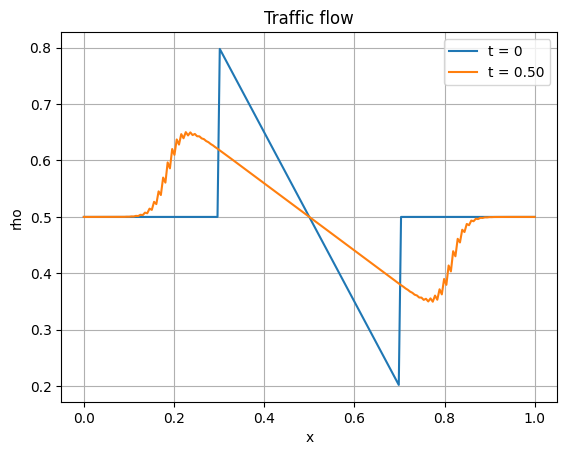

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


L = 1.0              
N = 200              
dx = L / N
x = np.linspace(0, L, N)

T = 0.5             
CFL = 0.8
dt = CFL * dx      
Nt = int(T / dt)

a, b = 0.3, 0.7
u_a = 0.8
u_b = 0.2
u_0 = 0.5

def f(u):
    return u * (1 - u)

u = np.zeros_like(x)
def u0(x):
    for j in range(N):
        if a <= x[j] <= b:
            u[j] = u_a + (u_b - u_a) * (x[j] - a) / (b - a)
        else:
            u[j] = u_0
    return u
u = u0(x)

plt.plot(x, u, label="t = 0")

for n in range(Nt):
    u_new = np.zeros_like(u)
    
    for j in range(N):
        jp = (j + 1) % N  
        jm = (j - 1) % N
        
        u_new[j] = 0.5 * (u[jp] + u[jm]) \
                   - (dt / (2 * dx)) * (f(u[jp]) - f(u[jm]))
    
    u = u_new

plt.plot(x, u, label="t = {:.2f}".format(T))
plt.xlabel("x")
plt.ylabel("rho")
plt.title("Traffic flow")
plt.legend()
plt.grid()
plt.show()

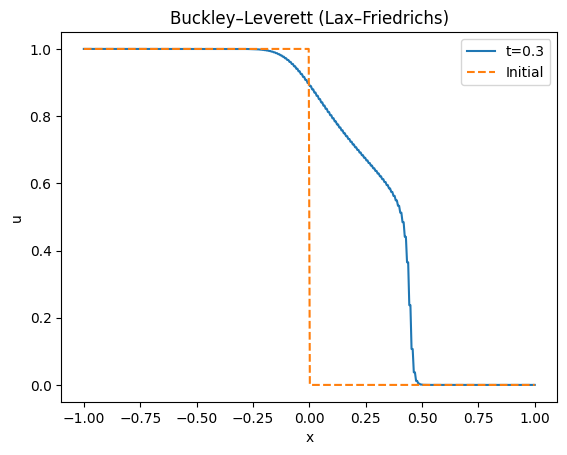

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Flux function
def f(u):
    return u**2 / (u**2 + 0.5*(1-u)**2)

# Grid
Nx = 400
x_min, x_max = -1, 1
dx = (x_max - x_min)/Nx
x = np.linspace(x_min, x_max, Nx)

# Time
dt = 0.4 * dx / 2   # CFL-safe
T = 0.3
Nt = int(T/dt)

# Initial condition
u = np.zeros(Nx)
u[x < 0] = 1
u0=u.copy()
# Time stepping
for n in range(Nt):
    u_new = np.copy(u)
    for i in range(1, Nx-1):
        u_new[i] = 0.5*(u[i+1] + u[i-1]) \
                   - (dt/(2*dx))*(f(u[i+1]) - f(u[i-1]))
    u = u_new

# Plot
plt.plot(x, u, label=f"t={T}")
plt.plot(x, u0, '--', label="Initial")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Buckley–Leverett (Lax–Friedrichs)")
plt.legend()
plt.show()